In [1]:
'''
Correct the ring artifacts in the calibration data for calibration_8_41
'''

'\nCorrect the ring artifacts in the calibration data for calibration_8_41\n'

In [2]:
import os
import SimpleITK as sitk
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage

from leapctype import tomographicModels

import pcct_md_diffusion.utils as utils
from pcct_md_diffusion.locations import base_input_dir

In [3]:
mu_waters = np.array([0.0196, 0.0192, 0.0186])
display_vmins = (-50 + 1000) / 1000 * mu_waters
display_vmaxs = (50 + 1000) / 1000 * mu_waters

brain_vmins = (0 + 1000) / 1000 * mu_waters
brain_vmaxs = (80 + 1000) / 1000 * mu_waters

Loading channel 0...
Loading channel 1...
Loading channel 2...


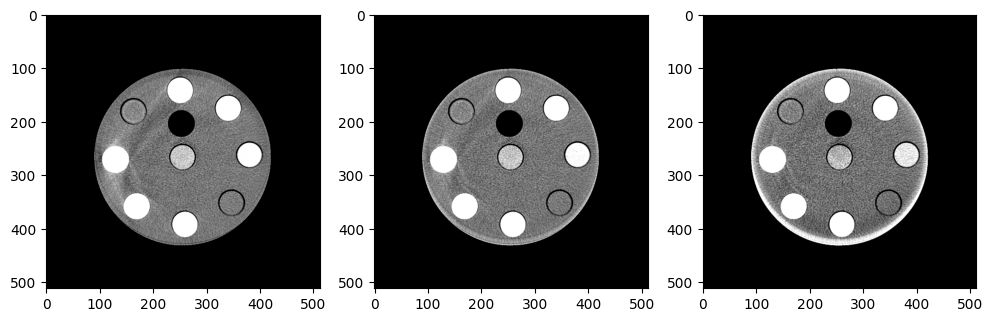

In [4]:
calibration_dir = os.path.join(base_input_dir, 'omnitom_pcd/calibration/calibration_8_41/img/1')
imgs, dx, dy, dz, sitk_ref = utils.load_image(calibration_dir, return_sitk_template=True)
imgs[imgs < -1000] = -1000

for i in range(3):
    imgs[i] = (imgs[i] + 1000) / 1000 * mu_waters[i]

imgs = imgs[:, [0], ...]  # only keep the first slice. The second slice has metal

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(imgs[i, 0], 'gray', vmin=display_vmins[i], vmax=display_vmaxs[i])
plt.show()


======== CT Parallel-Beam Geometry ========
number of angles: 720
number of detector elements (rows, cols): 1 x 1756
angular range: 180.000000 degrees
detector pixel size: 5.656000 mm x 0.175785 mm
center detector pixel: 0.000000, 877.500000

======== CT Volume ========
number of voxels (x, y, z): 512 x 512 x 1
voxel size: 0.601562 mm x 0.601562 mm x 5.656000 mm
FOV: [-154.000000, 154.000000] x [-154.000000, 154.000000] x [-2.828000, 2.828000]

======== Processing Settings ========
GPU processing on devices 0, 1, 2
Forward projecting...GPU with least amount of memory: 35.170753 GB


Channel 0
Channel 1
Channel 2
(3, 720, 1, 1756)


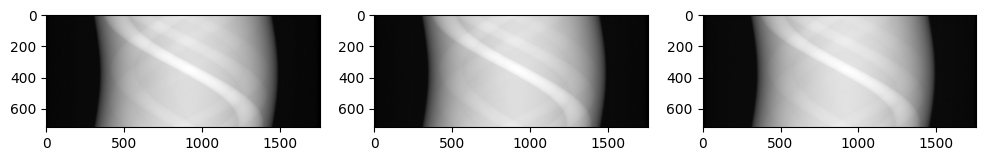

In [5]:
# forward projection
# geometry already after interleaving
geometry_path = os.path.join(base_input_dir, 'omnitom_pcd/geometry/omnitom_3x3_parallel_fov_308.cfg')
geo = utils.load_geometry(geometry_path)
geo.nx = imgs.shape[-1]
geo.ny = imgs.shape[-2]
geo.nz = imgs.shape[-3]
geo.nv = geo.nz
geo.dx = dx
geo.dy = dy
geo.dz = dz
geo.dv = dz
geo.nu *= 2
geo.du /= 2
geo.nview = 720
geo.off_u = 0
leapct = utils.set_leapct_geometry(geo, angles_in_deg=np.arange(0, 180, 180.0 / geo.nview).astype(np.float32))
leapct.print_parameters()

print('Forward projecting...', flush=True)
current_fp = leapct.allocate_projections()
prjs = []
for ch in range(imgs.shape[0]):
    print('Channel', ch, flush=True)
    leapct.project(current_fp, imgs[ch])
    prjs.append(np.copy(current_fp, 'C'))
prjs = np.array(prjs)

print(prjs.shape)

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(prjs[i, :, 0, :], 'gray')
plt.show()

Reconstructing...
Channel 0
Channel 1
Channel 2


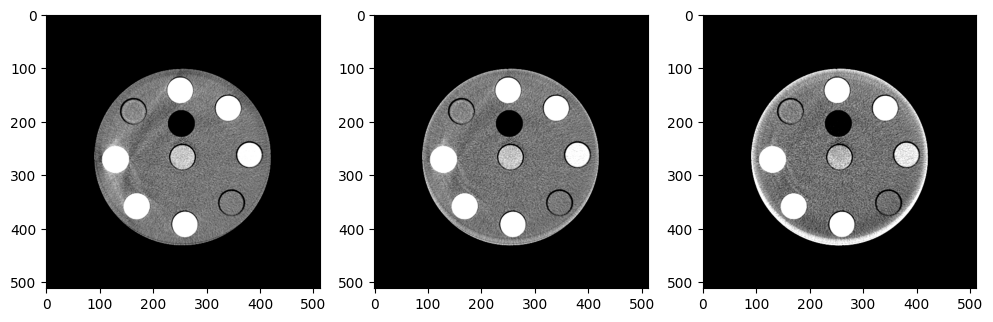

In [6]:
# validate reconstruction
print('Reconstructing...', flush=True)
fbps_origin = []
for ch in range(prjs.shape[0]):
    print('Channel', ch, flush=True)
    current_fbp = leapct.FBP(prjs[ch])
    fbps_origin.append(np.copy(current_fbp, 'C'))
fbps_origin = np.array(fbps_origin)

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(fbps_origin[i, 0], 'gray', vmin=display_vmins[i], vmax=display_vmaxs[i])
plt.show()

Boundary indices: 309 1446
Reconstructing...


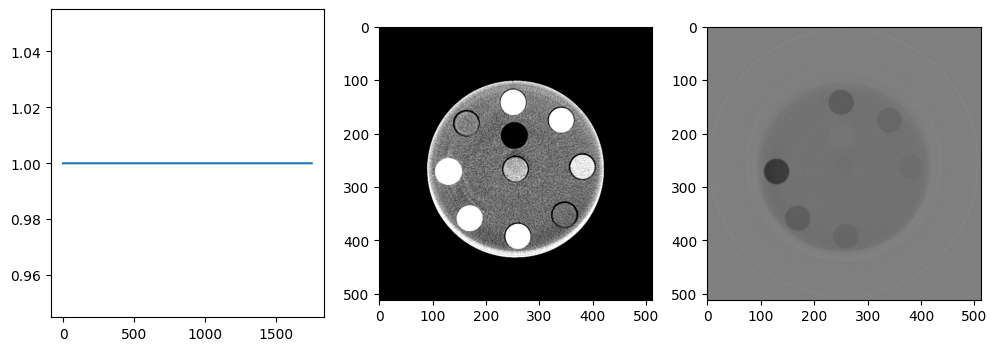

In [7]:
# test the boundary on channel 2
radius_mm = 200 / 2
left_margin = 20
right_margin = 0
magnitude = 1


radius_pixel = radius_mm / geo.du
istart = int(np.ceil((geo.nu - 1) / 2 - geo.off_u - radius_pixel))
iend = int(np.floor((geo.nu - 1) / 2 - geo.off_u + radius_pixel))
print('Boundary indices:', istart, iend)

correction_curve = np.ones(prjs.shape[-1])
# correction_curve[iend - left_margin:iend + right_margin] *= magnitude * np.linspace(0, 1, right_margin + left_margin) + 1 * np.linspace(1, 0, right_margin + left_margin)
correction_curve[iend - left_margin:iend + right_margin] *= 1 + np.cos(np.linspace(0, np.pi, right_margin + left_margin)) * (1 - magnitude) / 2 - (1 - magnitude) / 2
correction_curve[iend + right_margin:] *= magnitude


prjs_corrected = prjs.copy()
prjs_corrected[2, ...] *= correction_curve
# prjs_corrected[2, :, 0, :] += (correction_curve - 1) * 30

print('Reconstructing...', flush=True)
fbp = leapct.FBP(prjs_corrected[2])
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.plot(correction_curve)
plt.subplot(1, 3, 2)
plt.imshow(fbp[0], 'gray', vmin=display_vmins[2], vmax=display_vmaxs[2])
plt.subplot(1, 3, 3)
# plt.imshow(fbps_origin[2, 0], 'gray', vmin=display_vmins[2], vmax=display_vmaxs[2])
plt.imshow(fbps_origin[2, 0] - fbps_origin[0, 0], 'gray', vmin=-0.01, vmax=0.01)

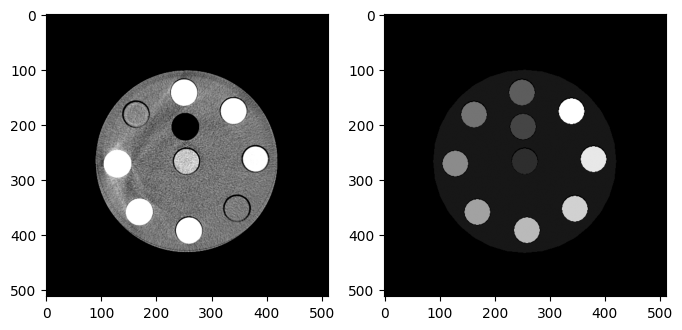

In [8]:
# load segmentation mask
sitk_mask = sitk.ReadImage(os.path.join(calibration_dir, 'segmentation.seg.nrrd'))
mask = sitk.GetArrayFromImage(sitk_mask)
mask = mask[[0], ...]  # only keep the first slice. The second slice has metal

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(imgs[0, 0], 'gray', vmin=display_vmins[0], vmax=display_vmaxs[0])
plt.subplot(1, 2, 2)
plt.imshow(mask[0], 'gray')

Forward projecting...
Channel 0
Channel 1
Channel 2


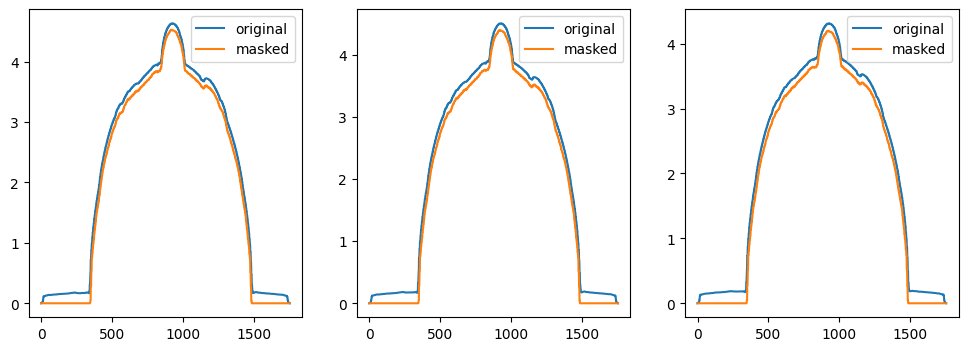

In [9]:
# cut off the area outside the phantom (foam) then do forward projection

phantom_mask = np.where(mask > 0, 1, 0)
# fill hole slice by slice
for i in range(phantom_mask.shape[0]):
    phantom_mask[i] = scipy.ndimage.binary_fill_holes(phantom_mask[i])

# set to air outside the phantom
imgs_masked = imgs.copy()
for ch in range(imgs.shape[0]):
    imgs_masked[ch] = np.where(phantom_mask > 0, imgs[ch], 0)

# forward projection
print('Forward projecting...', flush=True)
current_fp = leapct.allocate_projections()
prjs_masked = []
for ch in range(imgs_masked.shape[0]):
    print('Channel', ch, flush=True)
    leapct.project(current_fp, imgs_masked[ch])
    prjs_masked.append(np.copy(current_fp, 'C'))
prjs_masked = np.array(prjs_masked)

# compare projection with original projection
plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.plot(prjs[i, prjs.shape[1] // 2, 0, :], label='original')
    plt.plot(prjs_masked[i, prjs_masked.shape[1] // 2, 0, :], label='masked')
    plt.legend()

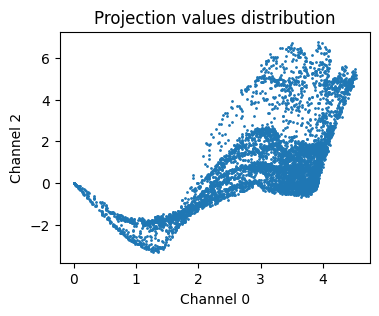

In [10]:
# demonstrate projection 2D distributions for the look up table
# only do it for ch 0 and ch 1

np.random.seed(0)
vals_ch0 = prjs_masked[0, :, 0, :].flatten()
vals_ch2 = prjs_masked[2, :, 0, :].flatten()
inds = np.random.choice(len(vals_ch0), size=10000, replace=False)

plt.figure(figsize=(4, 3))
plt.scatter(vals_ch0[inds], vals_ch0[inds] / mu_waters[0] - vals_ch2[inds] / mu_waters[2], s=1)
plt.xlabel('Channel 0')
plt.ylabel('Channel 2')
plt.title('Projection values distribution')
plt.show()


Loading channel 0...
Loading channel 1...
Loading channel 2...


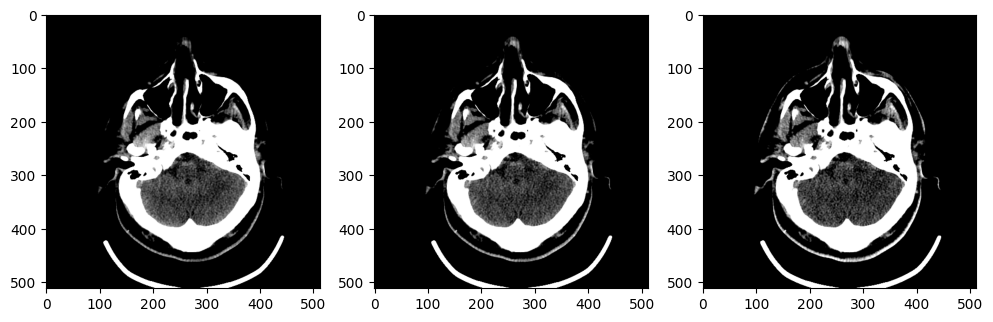

In [11]:
# check projection distribution in patient data
pt_dir = os.path.join(base_input_dir, 'omnitom_pcd/recon/img/26')
imgs_pt, _, _, _ = utils.load_image(pt_dir)
imgs_pt[imgs_pt < -1000] = -1000
for i in range(3):
    imgs_pt[i] = (imgs_pt[i] + 1000) / 1000 * mu_waters[i]

# average every 8 slices
nz = imgs_pt.shape[1]
nz_truncate = (nz // 8) * 8
imgs_pt = imgs_pt[:, :nz_truncate, ...].reshape(imgs_pt.shape[0], nz_truncate // 8, 8, imgs_pt.shape[2], imgs_pt.shape[3]).mean(axis=2)

plt.figure(figsize=(12, 4))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.imshow(imgs_pt[i, 7], 'gray', vmin=brain_vmins[i], vmax=brain_vmaxs[i])
plt.show()

In [12]:
# forward projection
print('Forward projecting...', flush=True)
current_fp = leapct.allocate_projections()
prjs_pt = []
for ch in range(imgs_pt.shape[0]):
    print('Channel', ch, flush=True)
    prjs_slices = []
    for islice in range(imgs_pt.shape[1]):
        current_img = np.copy(imgs_pt[ch, [islice]], 'C')
        leapct.project(current_fp, current_img)
        prjs_slices.append(np.copy(current_fp, 'C'))
    prjs_slices = np.concatenate(prjs_slices, axis=1)
    prjs_pt.append(prjs_slices)
prjs_pt = np.array(prjs_pt)

print(prjs_pt.shape)

Forward projecting...
Channel 0
Channel 1
Channel 2
(3, 720, 27, 1756)


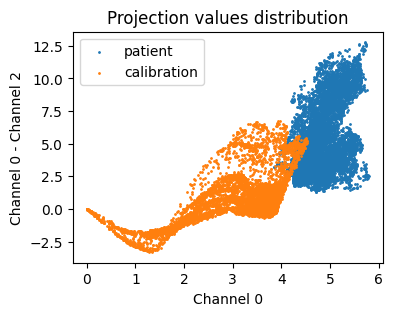

In [13]:
# draw the projection distribution for patient data along with the calibration data distribution for comparison
np.random.seed(0)
vals_ch0_calib = prjs_masked[0, :, 0, :].flatten()
vals_ch2_calib = prjs_masked[2, :, 0, :].flatten()
vals_ch0_pt = prjs_pt[0, :, 7, prjs_pt.shape[-1] // 2 - 100:prjs_pt.shape[-1] // 2 + 100].flatten()
vals_ch2_pt = prjs_pt[2, :, 7, prjs_pt.shape[-1] // 2 - 100:prjs_pt.shape[-1] // 2 + 100].flatten()
inds_calib = np.random.choice(len(vals_ch0_calib), size=10000, replace=False)
inds_pt = np.random.choice(len(vals_ch0_pt), size=10000, replace=False)

plt.figure(figsize=(4, 3))
plt.scatter(vals_ch0_pt[inds_pt], vals_ch0_pt[inds_pt] / mu_waters[0] - vals_ch2_pt[inds_pt] / mu_waters[2], s=1, label='patient')
plt.scatter(vals_ch0_calib[inds_calib], vals_ch0_calib[inds_calib] / mu_waters[0] - vals_ch2_calib[inds_calib] / mu_waters[2], s=1, label='calibration')
# plt.scatter(vals_ch0_calib[inds_calib], vals_ch2_calib[inds_calib], s=1, label='calibration')
# plt.scatter(vals_ch0_pt[inds_pt], vals_ch2_pt[inds_pt], s=1, label='patient')
plt.xlabel('Channel 0')
plt.ylabel('Channel 0 - Channel 2')
plt.title('Projection values distribution')
plt.legend()